## AGN FINAL PROJECT 
### Sona Davis
## TASK 3:
Using the quasar composite spectra from the SDSS survey (Vanden Berk et al. 2001) **estimate
the approximate contribution of the broad emission line emission to the six LSST bands
(ugrizy) at the following redshifts 0.5, 1.0, 1.5, 2.0, 2.5, 3.0**, assuming that the underlying
continuum is best described with the broken power-law (see Vanden Berk et al. 2001). In
addition, **consider the contribution of the strong emission lines (i.e. Lyα 1216, C IV 1549, C III]
1909, Mg II 2798, Hβ 4861, Hα 6563) to each of the six LSST bands (ugrizy)**. Describe in details
the used methodology. Useful tip: make use of the PhotoRM and fantasy notebook.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df3 = pd.read_csv("tab1.txt", sep=r"\s+") # table 1 from (Vanden Berk et al. 2001)
len(df3)

7755

In [5]:
df3.head()

,wavelength,flux_density,flux_density_uncertainity
0,800.5,0.149,0.074
1,801.5,0.000,0.260
2,802.5,0.676,0.227
3,803.5,0.000,0.222
4,804.5,0.413,0.159


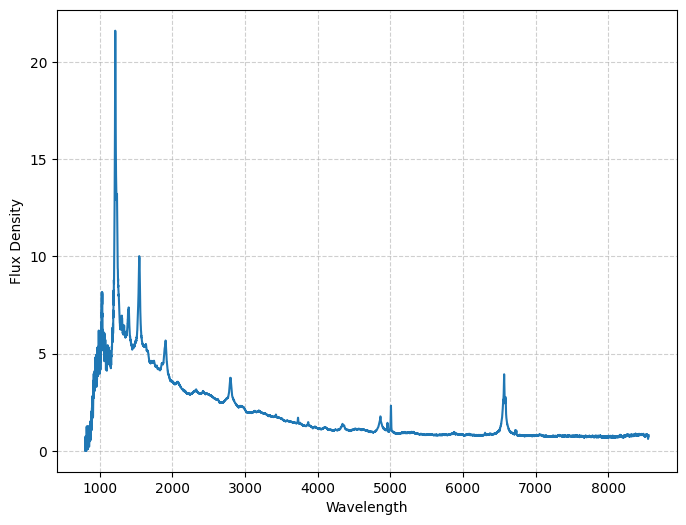

In [6]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df3,x='wavelength',y='flux_density')
plt.xlabel('Wavelength')
plt.ylabel('Flux Density')
plt.grid(True,linestyle='--',alpha=0.6)
plt.savefig('Table1.png', bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()

In [7]:
z = [0.5,1.0,1.5,2.0,2.5,3.0] # 6 different redshift cases
z1,z2,z3,z4,z5,z6 = [],[],[],[],[],[]
for i in range(7755):
    z1.append((1+z[0]) * df3['wavelength'][i])
    z2.append((1+z[1]) * df3['wavelength'][i])
    z3.append((1+z[2]) * df3['wavelength'][i])
    z4.append((1+z[3]) * df3['wavelength'][i])
    z5.append((1+z[4]) * df3['wavelength'][i])
    z6.append((1+z[5]) * df3['wavelength'][i])
df3['z1'] = z1
df3['z2'] = z2
df3['z3'] = z3
df3['z4'] = z4
df3['z5'] = z5
df3['z6'] = z6

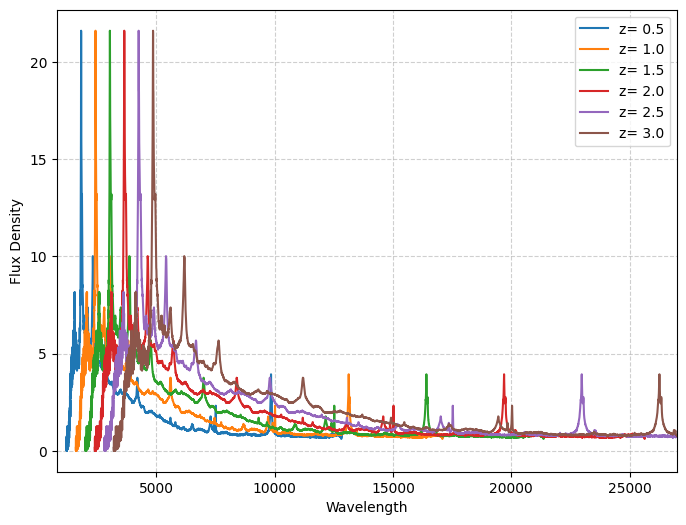

In [8]:
names = ['z1','z2','z3','z4','z5','z6']
plt.figure(figsize=(8,6))
for i in range(6):
    sns.lineplot(data=df3,x=names[i],y='flux_density',label=f'z= {z[i]}')
plt.xlim(800,27000)
#plt.ylim(-0.1,10.5)
plt.xlabel('Wavelength')
plt.ylabel('Flux Density')
plt.grid(True,linestyle='--',alpha=0.6)
plt.savefig('TASK 3 redshift.png', bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()

In [9]:
data_z05 = {'wavelength': df3['z1'],
           'flux' : df3['flux_density'],
           'flux_uncertainity' : df3['flux_density_uncertainity']}
data_z10 = {'wavelength': df3['z2'],
           'flux' : df3['flux_density'],
           'flux_uncertainity' : df3['flux_density_uncertainity']}
data_z15 = {'wavelength': df3['z3'],
           'flux' : df3['flux_density'],
           'flux_uncertainity' : df3['flux_density_uncertainity']}
data_z20 = {'wavelength': df3['z4'],
           'flux' : df3['flux_density'],
           'flux_uncertainity' : df3['flux_density_uncertainity']}
data_z25 = {'wavelength': df3['z5'],
           'flux' : df3['flux_density'],
           'flux_uncertainity' : df3['flux_density_uncertainity']}
data_z30 = {'wavelength': df3['z6'],
           'flux' : df3['flux_density'],
           'flux_uncertainity' : df3['flux_density_uncertainity']}


In [10]:
dfz05 = pd.DataFrame(data_z05)
dfz10 = pd.DataFrame(data_z10)
dfz15 = pd.DataFrame(data_z15)
dfz20 = pd.DataFrame(data_z20)
dfz25 = pd.DataFrame(data_z25)
dfz30 = pd.DataFrame(data_z30)

In [11]:
A = 0.0158
B = A*5200**2.01
df3['low'] = (A * df3['wavelength']**(0.45)) 
df3['high'] = (B * (df3['wavelength'])**(-1.56)) 

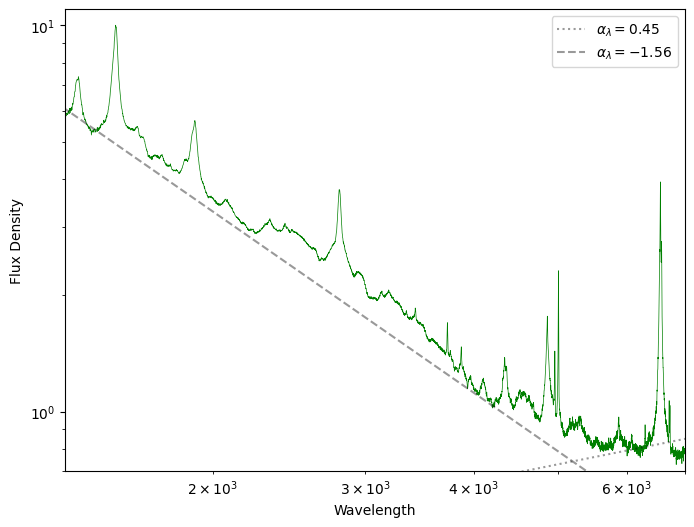

In [12]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df3,x='wavelength',y='flux_density',color='green',linewidth='0.5')
plt.xscale('log')
plt.yscale('log')
sns.lineplot(data=df3,x='wavelength',y='low',linestyle=':',color='black',label=r'$\alpha_\lambda = 0.45 $',alpha=0.4)
sns.lineplot(data=df3,x='wavelength',y='high',linestyle='--',color='black',label=r'$\alpha_\lambda = -1.56 $',alpha=0.4)
plt.xlim(1350,7000)
plt.ylim(0.7,11)
plt.xlabel('Wavelength')
plt.ylabel('Flux Density')
#plt.grid(True,linestyle='--',alpha=0.6)
plt.savefig('Task 3 Vanden Berk Image.png', bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()

In [13]:
df3['y'] = df3['flux_density']/100

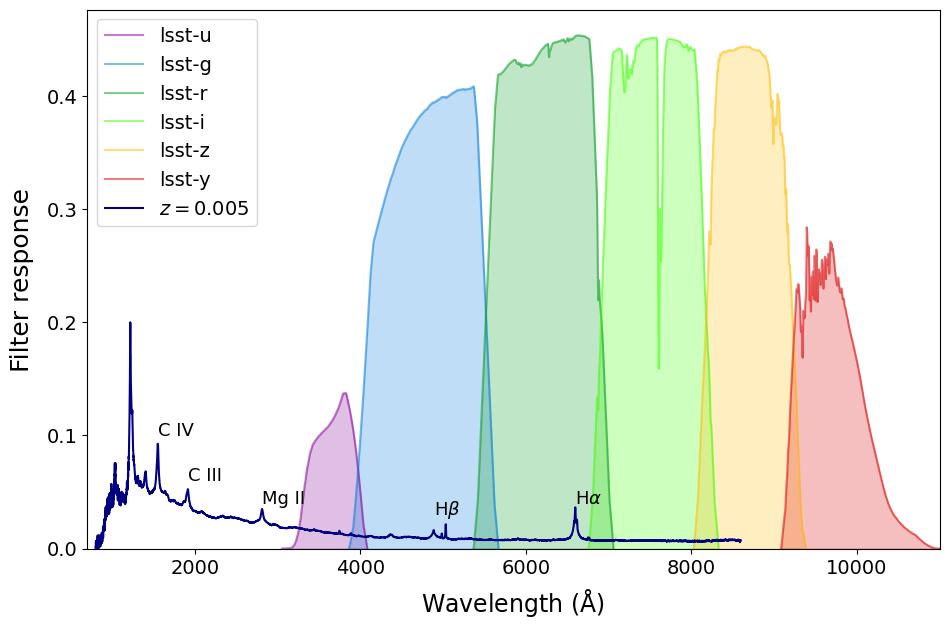

In [20]:
import photRM
#photRM.filters_viz(z=z[0], phot_sys='LSST', save=False, comp_spec_path='./data/',x=df3[names[0]],y=df3['y'])
photRM.filters_viz(z=0.005, phot_sys='LSST', save=False, comp_spec_path='./data/data/')
plt.savefig('LSST filters.png',bbox_inches='tight', pad_inches=0.1, transparent=True) 

In [21]:
#photRM.filters_viz(z=z[0], phot_sys='LSST', save=False, comp_spec_path='./data/data/',x=df3[names[0]],y=df3['y'])

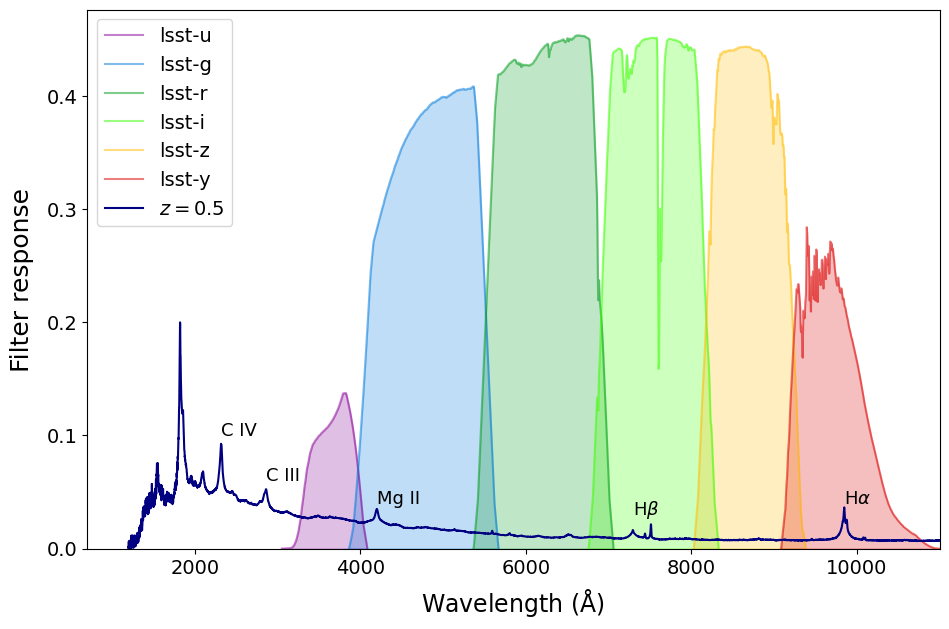

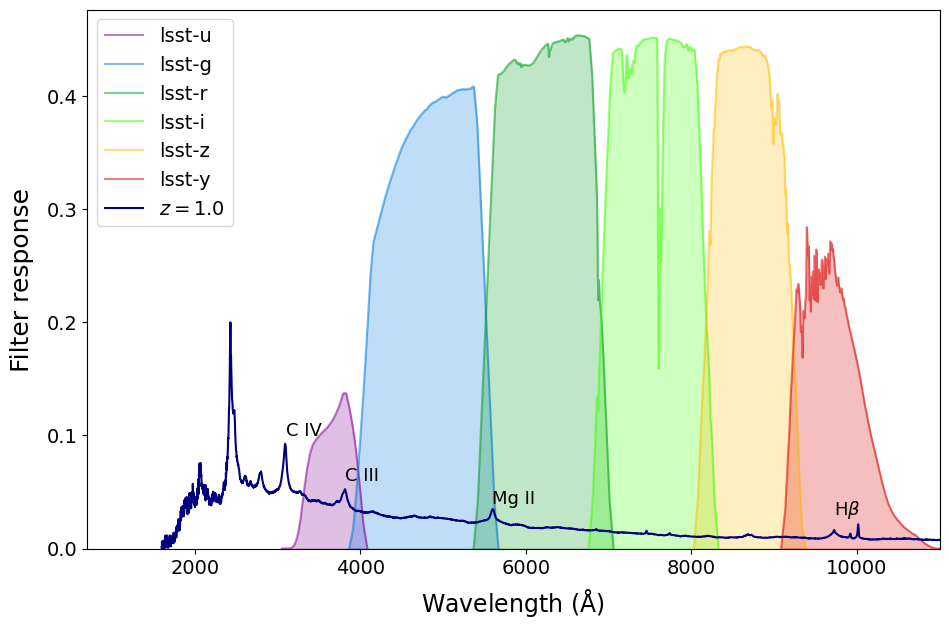

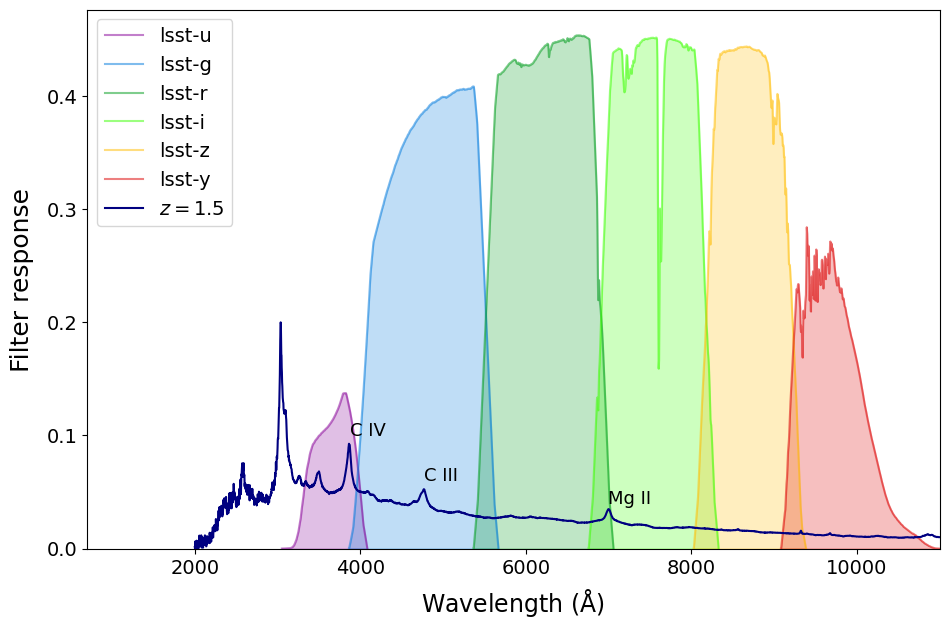

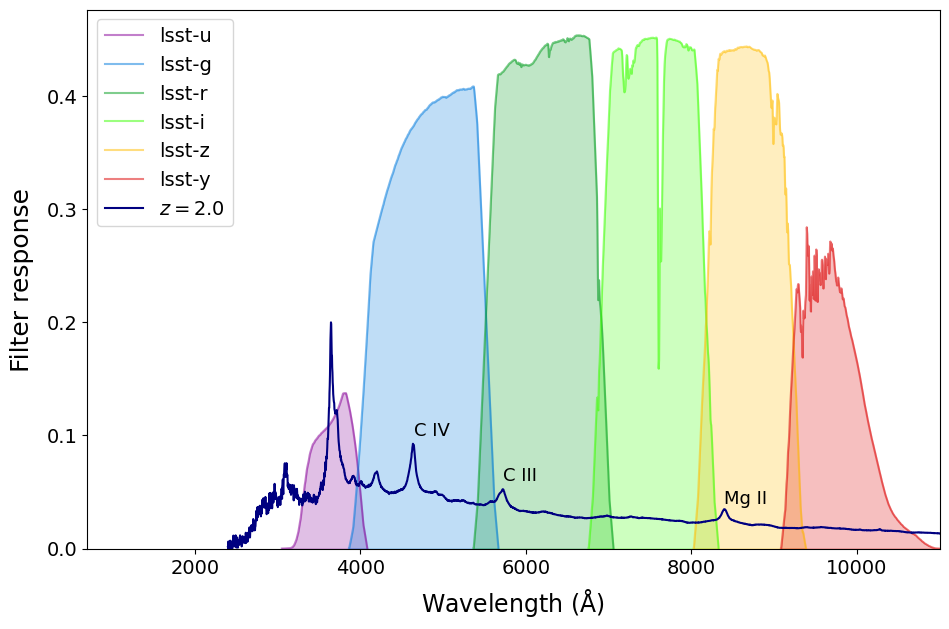

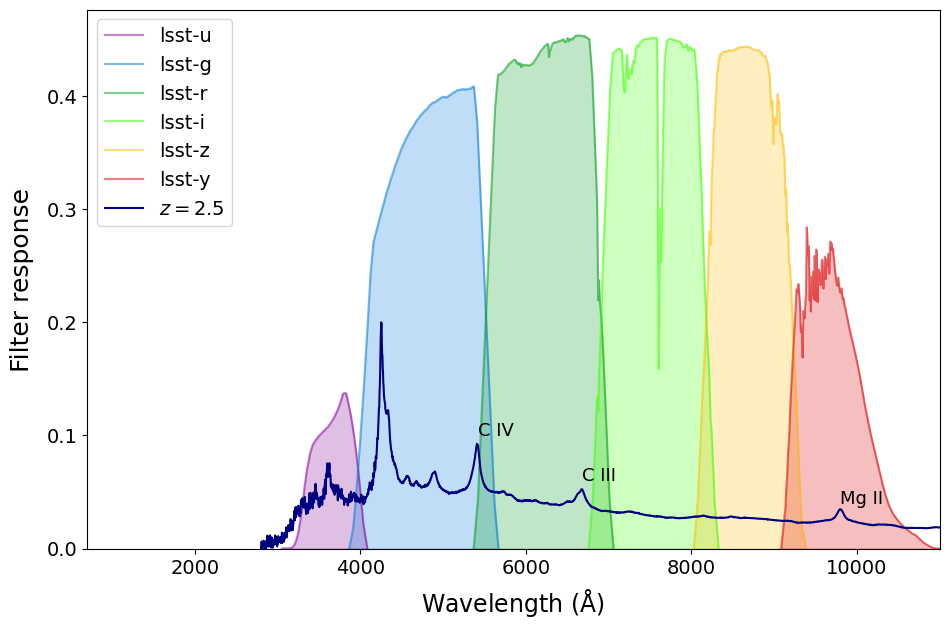

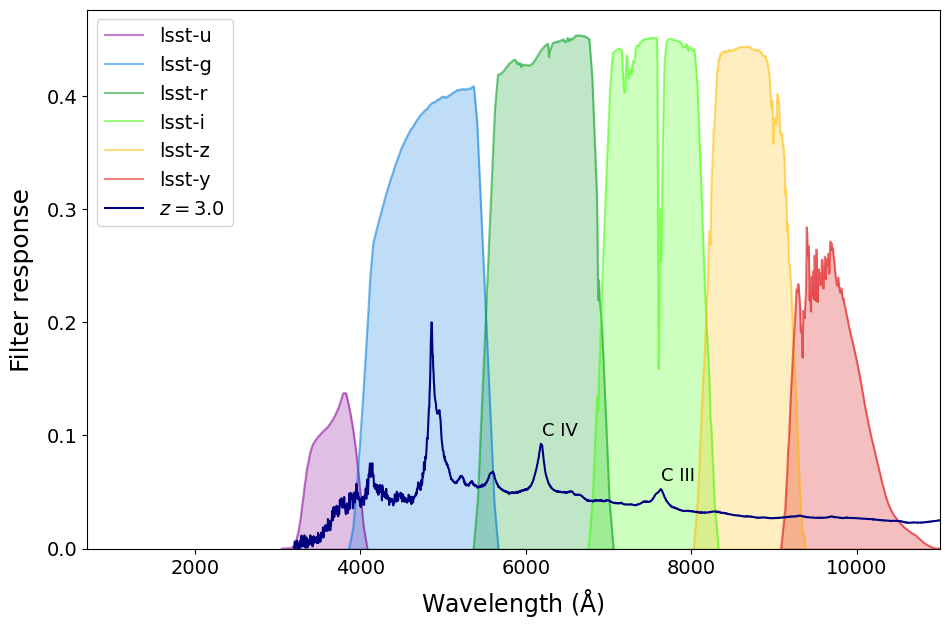

In [19]:
for i in range(6):
    #photRM.filters_viz(z=z[i], phot_sys='LSST', save=False, comp_spec_path='./data/data',x=df3[names[i]],y=df3['y'])
    photRM.filters_viz(z=z[i], phot_sys='LSST', save=False, comp_spec_path='./data/data/')
    
    plt.savefig(f'3.{i+1}.png', bbox_inches='tight', pad_inches=0)

This method of estimating the contribution to each band (and
the implementation of Fanstasy later) assumes that the underlying
continuum is best described with the broken power-law as described
in Vanden Berk et al. (2001)